In [ ]:
!pip install transformers_stream_generator
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM
import torch

model_id = "Qwen/Qwen-VL-Chat"

processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True
).to("cuda" if torch.cuda.is_available() else "cpu")


Loading checkpoint shards:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from PIL import Image
import json
import os

class MarksheetOCR:
    def __init__(self, model_name="Qwen/Qwen2-VL-72B-Instruct"):
        """
        Initialize the Qwen VLM model for marksheet OCR

        Args:
            model_name (str): Hugging Face model name
        """
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Using device: {self.device}")

        # Load model with optimizations for large models
        print("Loading model... This may take a few minutes...")
        self.model = Qwen2VLForConditionalGeneration.from_pretrained(
            model_name,
            torch_dtype=torch.float16,  # Use half precision to save memory
            device_map="auto",  # Automatically distribute across available GPUs
            trust_remote_code=True,
            attn_implementation="flash_attention_2"  # Use flash attention for efficiency
        )

        self.processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)

        print("Model loaded successfully!")

    def create_ocr_prompt(self):
        """
        Create a detailed prompt for accurate OCR extraction
        """
        prompt = """You are an expert OCR system specialized in extracting information from educational marksheets and certificates.

Please analyze this marksheet image and extract the following information with high accuracy:

1. **Student Name**: The full name of the student
2. **Guardian Name**: Father's name, Mother's name, or Guardian's name (whichever is present)
3. **Marks**: All numerical marks/grades obtained (extract only the numbers, not subject names)
4. **School Name**: The name of the educational institution

**Important Instructions:**
- Be extremely careful with text recognition, especially names and numbers
- For marks, extract only the numerical values (e.g., if you see "Mathematics: 85", extract only "85")
- Include all marks you can find, even if they are totals, percentages, or grades
- If any field is not clearly visible or uncertain, mark it as "Not Found"
- Maintain high accuracy over speed

**Output Format:**
Return ONLY a valid JSON object with this exact structure:
```json
{
    "student_name": "extracted student name",
    "guardian_name": "extracted guardian name",
    "marks": [list of numerical marks as strings],
    "school_name": "extracted school name"
}
```

Analyze the image carefully and provide the JSON response:"""

        return prompt

    def process_image(self, image_path):
        """
        Process the marksheet image and extract information

        Args:
            image_path (str): Path to the marksheet image

        Returns:
            dict: Extracted information in JSON format
        """
        # Load and validate image
        try:
            image = Image.open(image_path).convert("RGB")
            print(f"Image loaded successfully: {image.size}")
        except Exception as e:
            raise ValueError(f"Error loading image: {str(e)}")

        # Create the prompt
        prompt = self.create_ocr_prompt()

        # Prepare inputs for the model
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": prompt}
                ]
            }
        ]

        # Process inputs
        text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        image_inputs, video_inputs = self.processor.process_vision_info(messages)

        inputs = self.processor(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt"
        )
        inputs = inputs.to(self.device)

        # Generate response
        print("Processing image... This may take a moment...")
        with torch.no_grad():
            generated_ids = self.model.generate(
                **inputs,
                max_new_tokens=512,
                do_sample=False,  # Use deterministic generation for consistency
                temperature=0.1,
                top_p=0.9,
                pad_token_id=self.processor.tokenizer.eos_token_id
            )

        # Decode the response
        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]

        response = self.processor.batch_decode(
            generated_ids_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[0]

        return self.parse_response(response)

    def parse_response(self, response):
        """
        Parse the model response and extract JSON

        Args:
            response (str): Raw model response

        Returns:
            dict: Parsed JSON data
        """
        try:
            # Look for JSON in the response
            start_idx = response.find('{')
            end_idx = response.rfind('}') + 1

            if start_idx != -1 and end_idx != -1:
                json_str = response[start_idx:end_idx]
                parsed_data = json.loads(json_str)

                # Validate the structure
                required_keys = ['student_name', 'guardian_name', 'marks', 'school_name']
                for key in required_keys:
                    if key not in parsed_data:
                        parsed_data[key] = "Not Found"

                # Ensure marks is a list
                if not isinstance(parsed_data['marks'], list):
                    parsed_data['marks'] = []

                return parsed_data
            else:
                raise ValueError("No JSON found in response")

        except json.JSONDecodeError as e:
            print(f"JSON parsing error: {e}")
            print(f"Raw response: {response}")

            # Return a default structure if parsing fails
            return {
                "student_name": "Parsing Error",
                "guardian_name": "Parsing Error",
                "marks": [],
                "school_name": "Parsing Error",
                "raw_response": response
            }

def process_marksheet(image_path, output_path=None, model_name="Qwen/Qwen2-VL-72B-Instruct"):
    """
    Process a marksheet image and extract information

    Args:
        image_path (str): Path to the marksheet image
        output_path (str, optional): Path to save JSON output
        model_name (str): Qwen VLM model name

    Returns:
        dict: Extracted information
    """
    # Validate image path
    if not os.path.exists(image_path):
        print(f"Error: Image file not found at {image_path}")
        return None

    try:
        # Initialize the OCR system
        ocr_system = MarksheetOCR(model_name=model_name)

        # Process the image
        result = ocr_system.process_image(image_path)

        # Display results
        print("\n" + "="*50)
        print("EXTRACTED INFORMATION:")
        print("="*50)
        print(json.dumps(result, indent=2, ensure_ascii=False))

        # Save to file if specified
        if output_path:
            with open(output_path, 'w', encoding='utf-8') as f:
                json.dump(result, f, indent=2, ensure_ascii=False)
            print(f"\nResults saved to: {output_path}")

        return result

    except Exception as e:
        print(f"Error: {str(e)}")
        return None

# Quick test function for Colab
def test_with_sample():
    """
    Test function - replace with your actual image path
    """
    image_path = "abhinav.jpg"  # Update this path
    result = process_marksheet(image_path)
    return result

# Example usage in Colab:
#
# 1. Upload your marksheet image to Colab
# 2. Run the script:
#    result = process_marksheet('path/to/your/marksheet.jpg')
#
# 3. Or save to file:
#    result = process_marksheet('marksheet.jpg', 'results.json')
#
# 4. Access the data:
#    print(f"Student: {result['student_name']}")
#    print(f"Marks: {result['marks']}")

print("Marksheet OCR script loaded successfully!")
print("Usage: result = process_marksheet('abhinav.jpg')")

Marksheet OCR script loaded successfully!
Usage: result = process_marksheet('abhinav.jpg')


In [ ]:
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor
from PIL import Image
import json
import os

class MarksheetOCR:
    def __init__(self, model_name="Qwen/Qwen2-VL-72B-Instruct"):
        """
        Initialize the Qwen VLM model for marksheet OCR - Optimized for A100 40GB

        Args:
            model_name (str): Hugging Face model name
        """
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"Using device: {self.device}")

        # A100 40GB specific optimizations
        if torch.cuda.is_available():
            gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3
            print(f"GPU Memory: {gpu_memory:.1f} GB (A100 40GB detected)")

        # Load model with A100 40GB optimizations
        print("Loading Qwen2-VL-72B-Instruct model optimized for A100 40GB...")

        # Check if flash attention is available
        try:
            import flash_attn
            attn_implementation = "flash_attention_2"
            print("Using Flash Attention 2 for maximum performance...")
        except ImportError:
            attn_implementation = "sdpa"  # Scaled Dot Product Attention (built-in PyTorch)
            print("Flash Attention 2 not available, using SDPA (still very fast on A100)")

        self.model = Qwen2VLForConditionalGeneration.from_pretrained(
            model_name,
            torch_dtype=torch.float16,  # float16 optimal for A100 40GB
            device_map="auto",  # Automatically distribute across GPU
            trust_remote_code=True,
            attn_implementation=attn_implementation,  # Use available attention mechanism
            max_memory={0: "38GB"},  # Leave 2GB headroom for processing
            load_in_8bit=False,  # A100 40GB can handle full 16-bit precision
            low_cpu_mem_usage=True
        )

        self.processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)

        print("Qwen2-VL-72B-Instruct model loaded successfully on A100 40GB!")

    def create_ocr_prompt(self):
        """
        Create a detailed prompt for accurate OCR extraction
        """
        prompt = """You are an expert OCR system specialized in extracting information from educational marksheets and certificates.

Please analyze this marksheet image and extract the following information with high accuracy:

1. **Student Name**: The full name of the student
2. **Guardian Name**: Father's name, Mother's name, or Guardian's name (whichever is present)
3. **Marks**: All numerical marks/grades obtained (extract only the numbers, not subject names)
4. **School Name**: The name of the educational institution

**Important Instructions:**
- Be extremely careful with text recognition, especially names and numbers
- For marks, extract only the numerical values (e.g., if you see "Mathematics: 85", extract only "85")
- Include all marks you can find, even if they are totals, percentages, or grades
- If any field is not clearly visible or uncertain, mark it as "Not Found"
- Maintain high accuracy over speed

**Output Format:**
Return ONLY a valid JSON object with this exact structure:
```json
{
    "student_name": "extracted student name",
    "guardian_name": "extracted guardian name",
    "marks": [list of numerical marks as strings],
    "school_name": "extracted school name"
}
```

Analyze the image carefully and provide the JSON response:"""

        return prompt

    def process_image(self, image_path):
        """
        Process the marksheet image and extract information

        Args:
            image_path (str): Path to the marksheet image

        Returns:
            dict: Extracted information in JSON format
        """
        # Load and validate image
        try:
            image = Image.open(image_path).convert("RGB")
            print(f"Image loaded successfully: {image.size}")
        except Exception as e:
            raise ValueError(f"Error loading image: {str(e)}")

        # Create the prompt
        prompt = self.create_ocr_prompt()

        # Prepare inputs for the model using the correct Qwen2VL format
        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image,
                    },
                    {"type": "text", "text": prompt},
                ],
            }
        ]

        # Apply chat template and process inputs
        text = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )

        # Process the inputs correctly for Qwen2VL
        inputs = self.processor(
            text=text,
            images=image,
            return_tensors="pt",
            padding=True
        )
        inputs = inputs.to(self.device)

        # Generate response with A100 optimizations
        print("Processing image with A100 optimizations...")
        with torch.no_grad():
            generated_ids = self.model.generate(
                **inputs,
                max_new_tokens=512,
                do_sample=False,  # Deterministic for consistency
                temperature=0.1,
                top_p=0.9,
                pad_token_id=self.processor.tokenizer.eos_token_id,
                use_cache=True  # A100 has enough memory for caching
            )

        # Decode the response
        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]

        response = self.processor.batch_decode(
            generated_ids_trimmed,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False
        )[0]

        return self.parse_response(response)

    def parse_response(self, response):
        """
        Parse the model response and extract JSON

        Args:
            response (str): Raw model response

        Returns:
            dict: Parsed JSON data
        """
        try:
            # Look for JSON in the response
            start_idx = response.find('{')
            end_idx = response.rfind('}') + 1

            if start_idx != -1 and end_idx != -1:
                json_str = response[start_idx:end_idx]
                parsed_data = json.loads(json_str)

                # Validate the structure
                required_keys = ['student_name', 'guardian_name', 'marks', 'school_name']
                for key in required_keys:
                    if key not in parsed_data:
                        parsed_data[key] = "Not Found"

                # Ensure marks is a list
                if not isinstance(parsed_data['marks'], list):
                    parsed_data['marks'] = []

                return parsed_data
            else:
                raise ValueError("No JSON found in response")

        except json.JSONDecodeError as e:
            print(f"JSON parsing error: {e}")
            print(f"Raw response: {response}")

            # Return a default structure if parsing fails
            return {
                "student_name": "Parsing Error",
                "guardian_name": "Parsing Error",
                "marks": [],
                "school_name": "Parsing Error",
                "raw_response": response
            }

def process_marksheet(image_path, output_path=None, model_name="Qwen/Qwen2-VL-72B-Instruct"):
    """
    Process a marksheet image and extract information - A100 40GB Optimized

    Args:
        image_path (str): Path to the marksheet image
        output_path (str, optional): Path to save JSON output
        model_name (str): Qwen VLM model name (default: 72B for maximum accuracy)

    Returns:
        dict: Extracted information
    """
    # Validate image path
    if not os.path.exists(image_path):
        print(f"Error: Image file not found at {image_path}")
        return None

    try:
        # Initialize the OCR system
        ocr_system = MarksheetOCR(model_name=model_name)

        # Process the image
        result = ocr_system.process_image(image_path)

        # Display results
        print("\n" + "="*50)
        print("EXTRACTED INFORMATION (A100 40GB):")
        print("="*50)
        print(json.dumps(result, indent=2, ensure_ascii=False))

        # Save to file if specified
        if output_path:
            with open(output_path, 'w', encoding='utf-8') as f:
                json.dump(result, f, indent=2, ensure_ascii=False)
            print(f"\nResults saved to: {output_path}")

        return result

    except Exception as e:
        print(f"Error: {str(e)}")
        return None

# Quick test function for Colab
def test_with_sample():
    """
    Test function - replace with your actual image path
    """
    image_path = "abhinav.jpg"  # Update this path
    result = process_marksheet(image_path)
    return result

# Example usage in Colab:
#
# 1. Upload your marksheet image to Colab
# 2. Run the script:
#    result = process_marksheet('path/to/your/marksheet.jpg')
#
# 3. Or save to file:
#    result = process_marksheet('marksheet.jpg', 'results.json')
#
# 4. Access the data:
#    print(f"Student: {result['student_name']}")
#    print(f"Marks: {result['marks']}")

print("Marksheet OCR script loaded successfully for A100 40GB!")
print("Model: Qwen2-VL-72B-Instruct (Maximum accuracy)")
print("Usage: result = process_marksheet('abhinav.jpg')")
print("Expected model size: ~35GB VRAM usage on A100 40GB")

Marksheet OCR script loaded successfully for A100 40GB!
Model: Qwen2-VL-72B-Instruct (Maximum accuracy)
Usage: result = process_marksheet('abhinav.jpg')
Expected model size: ~35GB VRAM usage on A100 40GB


In [ ]:
# Go to https://huggingface.co/settings/tokens
# Create a token and add it to Colab secrets as 'HF_TOKEN'
# Or login directly:
from huggingface_hub import login
login()  # This will prompt you to enter your token

In [ ]:
# Install Flash Attention 2 for maximum A100 performance
!pip install flash-attn --no-build-isolation

# If that fails, try:
!pip install flash-attn==2.5.8 --no-build-isolation

# Then restart your runtime and run the script again

  Using cached flash_attn-2.5.8.tar.gz (2.5 MB)
  Preparing metadata (setup.py) ... done
  Using cached ninja-1.11.1.4-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.0 kB)
Using cached ninja-1.11.1.4-py3-none-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (422 kB)
ERROR: Operation cancelled by user

In [ ]:
!pip install bitsandbytes accelerate
result = process_marksheet('abhinav.jpg')

Using device: cuda
GPU Memory: 39.6 GB (A100 40GB detected)
Loading Qwen2-VL-72B-Instruct model optimized for A100 40GB...
Flash Attention 2 not available, using SDPA (still very fast on A100)


Loading checkpoint shards:   0%|          | 0/38 [00:00<?, ?it/s]

Qwen2-VL-72B-Instruct model loaded successfully on A100 40GB!
Image loaded successfully: (1200, 1005)


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Processing image with A100 optimizations...


In [ ]:
print(f"Student Name: {result['student_name']}")
print(f"Guardian Name: {result['guardian_name']}")
print(f"Marks: {result['marks']}")
print(f"School Name: {result['school_name']}")

TypeError: 'NoneType' object is not subscriptable

In [ ]:
!pip install pytesseract
import cv2
import pytesseract

In [ ]:
img = cv2.imread('abhinav.jpg')

In [ ]:
def ocr(img):
  text = pytesseract.image_to_string(img)
  return text

In [ ]:
def grayscale(image):
  return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [ ]:
def remove_noise(image):
  return cv2.medianBlur(image, 5)

In [ ]:
def thresholding(image):
  return cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

In [ ]:
img = grayscale(img)
img = thresholding(img)
img = remove_noise(img)

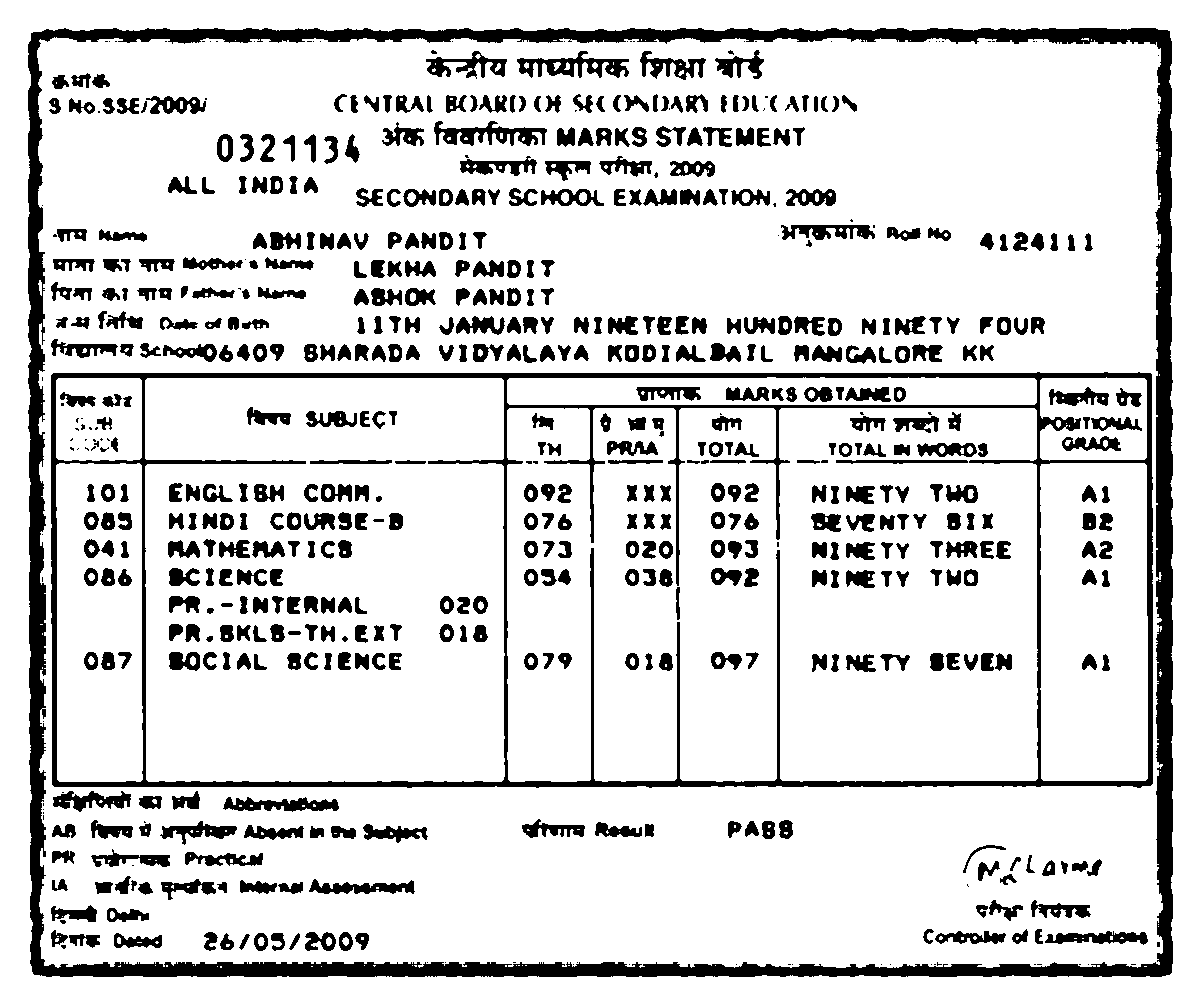

In [ ]:
from google.colab.patches import cv2_imshow
cv2_imshow(img)

In [ ]:
print(ocr(img))

W590 oy gene pe ee eee
eh A ce... tome ~ - . . pa n ~ oe a em ee
wedra wreafar faen até, feat CP ar een ee, )
? Centeal Roard of Secondary Educution, Delhl Reg:strat-on Ki cu 1 19
4, 3207073 wrocfrs: farorara yee (A + 2011-13) “9 ©. G14304015700
SECONDARY SCHOOL EN AMINATION OESSION : SOLE 201

‘ear et wr aire wre frome WATT WA Grade Sheet cum Certificate of Verfurmance

ae mete fan net Tht is to cert.ty (hat TT oo:

wen Rem ears or og ASHA RANI sTPmE Re tio. : 2158156
Motte a Fottee </Guor dns Plame JAWAHAR LAL .

rt OD Date ef tath 28/10/1997 28TH OCTOBER NINETEEN HUNORED NINETY SEVEN |

(tea Seno 04015-K V NO. 1 CHANDIMANDIR CANTT HARYANA 7 “ov

   
 
  

at Perce Pemyart itt nos pretoemed 03 fotows *

j

|

j

|

t: 1 Were AeNS4 Academic Performance : MTT Pare.y MOR AT ocr siacte Areas q
{; SRE bs Sa [og ee
+ !
}

; }
)
j

 

 

 

   

Pa Tee ee tai ae [ween ee”
“491 ENGLISH COMM’ " "Taf 1 -By “BI ae fe ew Tere lane per 8 te OTT vie OV iN2 Poot et ie
1 | 08 AZT R AY 10 BM elie xe 

EASYOCR approach

In [ ]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 25.3 MB/s eta 0:00:00


In [ ]:
import easyocr
import cv2
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
img_path = 'abhinav.jpg'

In [ ]:
reader = easyocr.Reader(['en'], gpu=True)
result = reader.readtext(img_path)
result

[([[np.int32(116), np.int32(45)],
   [np.int32(381), np.int32(45)],
   [np.int32(381), np.int32(81)],
   [np.int32(116), np.int32(81)]],
  'TFRK EOARD GF',
  np.float64(0.17661302188593617)),
 ([[np.int32(421), np.int32(47)],
   [np.int32(635), np.int32(47)],
   [np.int32(635), np.int32(85)],
   [np.int32(421), np.int32(85)]],
  '8744 4r8zf4ar',
  np.float64(0.1105165219746306)),
 ([[np.int32(711), np.int32(47)],
   [np.int32(1133), np.int32(47)],
   [np.int32(1133), np.int32(85)],
   [np.int32(711), np.int32(85)]],
  '4& CENTEA{ FoKFD GF <',
  np.float64(0.05257257352514202)),
 ([[np.int32(46), np.int32(68)],
   [np.int32(114), np.int32(68)],
   [np.int32(114), np.int32(94)],
   [np.int32(46), np.int32(94)]],
  '77a5',
  np.float64(0.15483608841896057)),
 ([[np.int32(43), np.int32(83)],
   [np.int32(1151), np.int32(83)],
   [np.int32(1151), np.int32(119)],
   [np.int32(43), np.int32(119)]],
  'S.No.SSEI2009/ Ef" €FC/ TCENTRAL BOARD OF SECONDARY EDUCATION 0/FN FREFEATTCAE',
  np.float6

In [ ]:
text = []
for i in range(0,len(result)):
  text.append(result[i][1])

In [ ]:
top_left = tuple(result[0][0][0])
bottom_right = tuple(result[0][0][2])
text = result[0][1]
font = cv2.FONT_HERSHEY_SIMPLEX

In [ ]:
!pip install mistralai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.6/411.6 kB 34.1 MB/s eta 0:00:00


In [ ]:
print(text)

['TFRK EOARD GF', '8744 4r8zf4ar', '4& CENTEA{ FoKFD GF <', '77a5', 'S.No.SSEI2009/ Ef" €FC/ TCENTRAL BOARD OF SECONDARY EDUCATION 0/FN FREFEATTCAE', 'ENTRA : 0321134', '3i75 farrfutant MARKS STATEMENT', 'RETTE6 FOfFG OFCE', 'eke', 'Aavustt Fa 4aw; 2009', 'SEGONEARL FEUCA TTON', 'ALL', 'INDIA', 'SECONDARY SCHOOL EXAMINATION; 2009', 'DER', 'Kel ', 'Lt', 'FOAFO OFSE', '7TA Name', 'ABHINAV', 'PANDIT', 'FORRP QF 42142476 Rol No', '41241416', "TTTT =T 7TA Mother's Name", 'LEKHA', 'PANDIT', "at 7TH Father's Name", 'Ashok', 'PANDIT', 'EPUCATICKE GFFTEELEORRROF E=', '57A', 'ffet', 'Date of Birth', '11TH', 'JANUARY', 'NINETEEN', 'HUNDRED', 'NINETY', 'FOUR', 'TION', 'fau1-T4 Schoolo6409', 'SHARADA', 'VIDYALAYA', 'KODIALBAIL', 'MANGALORE', 'Kk', 'TOD', 'faqa &rg', 'gera', 'MARKS OBTAINED', 'feriu i<', 'SUB', 'fqu]_SUBJECT', 'f', '4/316.4', '4T', '4TFat #', 'IPOSITIONAL', 'CODE', 'Th', 'PRIIA', 'TOTAL', 'TOTAL IN WORDS', 'GRADE', '101', 'ENGLISH', 'COMM_', '092', 'XXX', '092', 'NINETY', 'two', 'A1

In [ ]:
import requests
import json
from google.colab import userdata

def extract_manually(content, marksheet_text):
    import re
    result = {
        "name": None,
        "fathers_name": None,
        "mothers_name": None,
        "date_of_birth": None,
        "school_name": None,
        "marks": []
    }
    lines = content.split('\n')
    for line in lines:
        line = line.strip()
        if 'name' in line.lower() and 'father' not in line.lower() and 'mother' not in line.lower():
            name_match = re.search(r'name["\']?\s*:\s*["\']?([^"\'.,\n]+)', line, re.IGNORECASE)
            if name_match:
                result["name"] = name_match.group(1).strip()

        elif 'father' in line.lower():
            father_match = re.search(r'father["\']?\s*:\s*["\']?([^"\'.,\n]+)', line, re.IGNORECASE)
            if father_match:
                result["fathers_name"] = father_match.group(1).strip()

        elif 'mother' in line.lower():
            mother_match = re.search(r'mother["\']?\s*:\s*["\']?([^"\'.,\n]+)', line, re.IGNORECASE)
            if mother_match:
                result["mothers_name"] = mother_match.group(1).strip()

        elif 'birth' in line.lower() or 'dob' in line.lower():
            dob_match = re.search(r'(?:birth|dob)["\']?\s*:\s*["\']?([^"\'.,\n]+)', line, re.IGNORECASE)
            if dob_match:
                result["date_of_birth"] = dob_match.group(1).strip()

        elif 'school' in line.lower():
            school_match = re.search(r'school["\']?\s*:\s*["\']?([^"\'.,\n]+)', line, re.IGNORECASE)
            if school_match:
                result["school_name"] = school_match.group(1).strip()

        elif 'marks' in line.lower():
            marks_match = re.search(r'marks["\']?\s*:\s*\[(.*?)\]', line, re.IGNORECASE)
            if marks_match:
                marks_str = marks_match.group(1)
                marks = re.findall(r'\d+', marks_str)
                result["marks"] = [int(mark) for mark in marks]
    if not any(result.values()):
        result = extract_from_original_text(marksheet_text)

    return result

def extract_from_original_text(marksheet_text):
    import re

    result = {
        "name": None,
        "fathers_name": None,
        "mothers_name": None,
        "date_of_birth": None,
        "school_name": None,
        "marks": []
    }
    name_match = re.search(r'Name\s*:\s*([^,\n]+)', marksheet_text, re.IGNORECASE)
    if name_match:
        result["name"] = name_match.group(1).strip()
    father_match = re.search(r'Father[\'s]*\s*Name\s*:\s*([^,\n]+)', marksheet_text, re.IGNORECASE)
    if father_match:
        result["fathers_name"] = father_match.group(1).strip()
    mother_match = re.search(r'Mother[\'s]*\s*Name\s*:\s*([^,\n]+)', marksheet_text, re.IGNORECASE)
    if mother_match:
        result["mothers_name"] = mother_match.group(1).strip()
    dob_match = re.search(r'(?:Date\s*of\s*Birth|DOB)\s*:\s*([^,\n]+)', marksheet_text, re.IGNORECASE)
    if dob_match:
        result["date_of_birth"] = dob_match.group(1).strip()
    school_match = re.search(r'School\s*:\s*([^,\n]+)', marksheet_text, re.IGNORECASE)
    if school_match:
        result["school_name"] = school_match.group(1).strip()
    marks_pattern = r':\s*(\d+)'
    marks = re.findall(marks_pattern, marksheet_text)
    valid_marks = [int(mark) for mark in marks if 0 <= int(mark) <= 100]
    result["marks"] = valid_marks

    return result

def extract_student_info(text_list):
    api_key = userdata.get('Mistral_OCR')

    marksheet_text = ', '.join(text_list)
    prompt = f"""
    You are a data extraction expert. Extract ONLY the following information from this marksheet text and return it in valid JSON format.

    Marksheet text: {marksheet_text}

    Extract these fields:
    - name: Student's full name
    - fathers_name: Father's name
    - mothers_name: Mother's name
    - date_of_birth: Date of birth
    - school_name: School name
    - marks: Array of only numerical marks (exclude subject names, roll numbers, percentages)

    Return ONLY a valid JSON object in this exact format:
    {{"name": "value", "fathers_name": "value", "mothers_name": "value", "date_of_birth": "value", "school_name": "value", "marks": [numbers]}}

    Use null for missing information. Return only the JSON, no explanations.
    """
    url = "https://api.mistral.ai/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": "mistral-large-latest",
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],
        "temperature": 0.1,
        "max_tokens": 1000
    }

    try:
        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        result = response.json()
        content = result['choices'][0]['message']['content']

        try:
            student_info = json.loads(content)
            return student_info
        except json.JSONDecodeError:
            import re
            content_clean = content.strip()
            if content_clean.startswith('```json'):
                content_clean = content_clean[7:]
            if content_clean.endswith('```'):
                content_clean = content_clean[:-3]
            try:
                student_info = json.loads(content_clean)
                return student_info
            except json.JSONDecodeError:
                json_match = re.search(r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}', content_clean, re.DOTALL)
                if json_match:
                    try:
                        student_info = json.loads(json_match.group())
                        return student_info
                    except json.JSONDecodeError:
                        pass
                return extract_manually(content_clean, marksheet_text)

    except requests.exceptions.RequestException as e:
        return {"error": f"API request failed: {str(e)}"}
    except Exception as e:
        return {"error": f"Unexpected error: {str(e)}"}

def process_marksheet(text):
    result = extract_student_info(text)
    print("Extracted Student Information:")
    print(json.dumps(result, indent=2))

    return result

In [ ]:
import json

print("Processing marksheet data...")
print("="*50)

print("Input text being processed:")
print(text)
print("\nJoined text:")
print(', '.join(text))
print("\n" + "="*50)

try:
    extracted_data = process_marksheet(text)

    print("EXTRACTION COMPLETE")
    print("="*50)

    if "error" in extracted_data:
        print(f" Error occurred: {extracted_data['error']}")

        print("\n🔄 Attempting fallback extraction...")
        fallback_data = extract_from_original_text(', '.join(text))
        print("Fallback extraction result:")
        print(json.dumps(fallback_data, indent=2))

        if any(fallback_data.values()):
            print("\nFallback extraction successful!")
            extracted_data = fallback_data
    else:
        print("Successfully extracted student information:")
        print(json.dumps(extracted_data, indent=2))

    if not ("error" in extracted_data and "raw_response" not in extracted_data):
        with open('student_data.json', 'w') as f:
            json.dump(extracted_data, f, indent=2)

except Exception as e:
    print(f"❌ Execution error: {str(e)}")

    print("\n🔄 Attempting manual extraction as fallback...")
    try:
        manual_data = extract_from_original_text(', '.join(text))
        print("Manual extraction result:")
        print(json.dumps(manual_data, indent=2))
    except Exception as manual_error:
        print(f"Manual extraction also failed: {manual_error}")

Processing marksheet data...
Input text being processed:
['TFRK EOARD GF', '8744 4r8zf4ar', '4& CENTEA{ FoKFD GF <', '77a5', 'S.No.SSEI2009/ Ef" €FC/ TCENTRAL BOARD OF SECONDARY EDUCATION 0/FN FREFEATTCAE', 'ENTRA : 0321134', '3i75 farrfutant MARKS STATEMENT', 'RETTE6 FOfFG OFCE', 'eke', 'Aavustt Fa 4aw; 2009', 'SEGONEARL FEUCA TTON', 'ALL', 'INDIA', 'SECONDARY SCHOOL EXAMINATION; 2009', 'DER', 'Kel ', 'Lt', 'FOAFO OFSE', '7TA Name', 'ABHINAV', 'PANDIT', 'FORRP QF 42142476 Rol No', '41241416', "TTTT =T 7TA Mother's Name", 'LEKHA', 'PANDIT', "at 7TH Father's Name", 'Ashok', 'PANDIT', 'EPUCATICKE GFFTEELEORRROF E=', '57A', 'ffet', 'Date of Birth', '11TH', 'JANUARY', 'NINETEEN', 'HUNDRED', 'NINETY', 'FOUR', 'TION', 'fau1-T4 Schoolo6409', 'SHARADA', 'VIDYALAYA', 'KODIALBAIL', 'MANGALORE', 'Kk', 'TOD', 'faqa &rg', 'gera', 'MARKS OBTAINED', 'feriu i<', 'SUB', 'fqu]_SUBJECT', 'f', '4/316.4', '4T', '4TFat #', 'IPOSITIONAL', 'CODE', 'Th', 'PRIIA', 'TOTAL', 'TOTAL IN WORDS', 'GRADE', '101', 'ENG

In [ ]:
'''
import requests
import json
from google.colab import userdata

def extract_student_info(text_list):
    api_key = userdata.get('Mistral_OCR')
    marksheet_text = ', '.join(text_list)
    prompt = f"""
    Extract the following information from this marksheet text and return it in JSON format:

    Text: {marksheet_text}

    Please extract:
    1. Name (student's full name)
    2. Father's name
    3. Mother's name
    4. Date of birth (in DD/MM/YYYY or DD-MM-YYYY format if available)
    5. School name
    6. List of marks (only numerical values, exclude subject names)

    Return the response in this exact JSON format:
    {{
        "name": "extracted_name",
        "fathers_name": "extracted_fathers_name",
        "mothers_name": "extracted_mothers_name",
        "date_of_birth": "extracted_date",
        "school_name": "extracted_school_name",
        "marks": [list_of_numerical_marks]
    }}

    If any information is not found, use null for that field.
    Return only the JSON object, no additional text.
    """

    url = "https://api.mistral.ai/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    payload = {
        "model": "mistral-large-latest",
        "messages": [
            {
                "role": "user",
                "content": prompt
            }
        ],
        "temperature": 0.1,
        "max_tokens": 1000
    }

    try:
        response = requests.post(url, headers=headers, json=payload)
        response.raise_for_status()
        result = response.json()
        content = result['choices'][0]['message']['content']
        try:
            student_info = json.loads(content)
            return student_info
        except json.JSONDecodeError:
            import re
            json_match = re.search(r'\{.*\}', content, re.DOTALL)
            if json_match:
                student_info = json.loads(json_match.group())
                return student_info
            else:
                return {"error": "Could not parse JSON from response", "raw_response": content}

    except requests.exceptions.RequestException as e:
        return {"error": f"API request failed: {str(e)}"}
    except Exception as e:
        return {"error": f"Unexpected error: {str(e)}"}

def process_marksheet(text):
    result = extract_student_info(text)
    print("Extracted Student Information:")
    print(json.dumps(result, indent=2))

    return result
'''

In [ ]:
print("Processing marksheet data...")
print("="*50)

try:
    extracted_data = process_marksheet(text)

    print("\n" + "="*50)
    print("EXTRACTION COMPLETE")
    print("="*50)

    if "error" in extracted_data:
        print(f"Error occurred: {extracted_data['error']}")
        if "raw_response" in extracted_data:
            print(f"Raw response: {extracted_data['raw_response']}")
    else:
        print("Successfully extracted student information:")
        print(json.dumps(extracted_data, indent=2))

        with open('student_data.json', 'w') as f:
            json.dump(extracted_data, f, indent=2)
        print("\nData saved to 'student_data.json'")

except Exception as e:
    print(f"Execution error: {str(e)}")

Processing marksheet data...
Extracted Student Information:
{
  "error": "Unexpected error: Expecting ',' delimiter: line 7 column 24 (char 216)"
}

EXTRACTION COMPLETE
Error occurred: Unexpected error: Expecting ',' delimiter: line 7 column 24 (char 216)


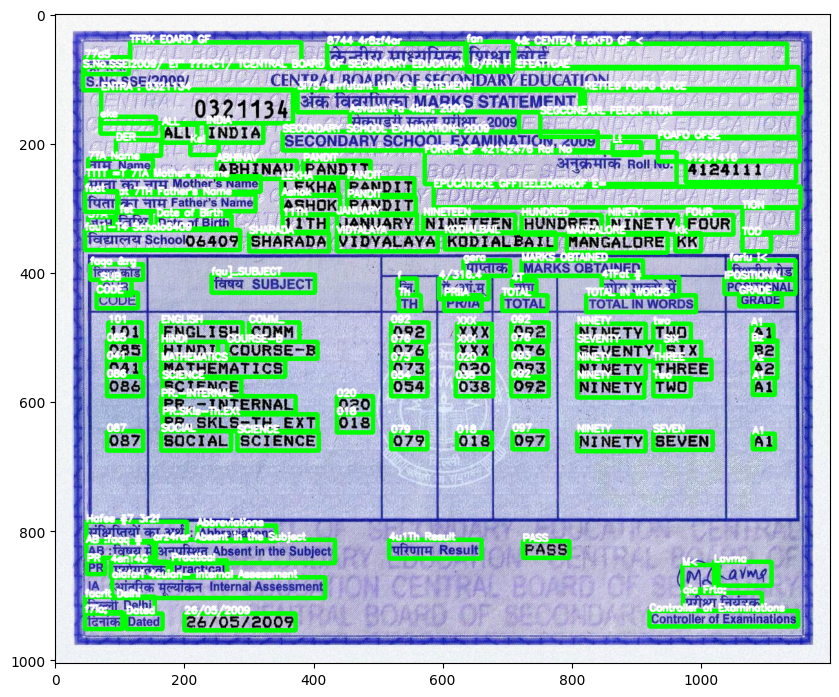

In [ ]:
img = cv2.imread(img_path)
for detection in result:
  top_left = tuple([int(val) for val in detection[0][0]])
  bottom_right = tuple([int(val) for val in detection[0][2]])
  text = detection[1]
  font = cv2.FONT_HERSHEY_SIMPLEX
  img = cv2.rectangle(img, top_left, bottom_right,(0,255,0),5)
  img = cv2.putText(img, text, top_left, font, 0.5, (255,255,255),2,cv2.LINE_AA)
plt.figure(figsize = (10,10))
plt.imshow(img)
plt.show()

In [ ]:
import spacy

In [ ]:
nlp = spacy.load("en_core_web_sm")

In [ ]:
doc = nlp("Marksheet Central Boarad Of Secondary Education Name of the candidate PRATHAM ASTHANA Father Name Upendra Kumar Asthana.")
for token in doc:
  print(token,"|", token.pos_)

Marksheet | NOUN
Central | PROPN
Boarad | PROPN
Of | ADP
Secondary | PROPN
Education | PROPN
Name | NOUN
of | ADP
the | DET
candidate | NOUN
PRATHAM | NOUN
ASTHANA | VERB
Father | PROPN
Name | PROPN
Upendra | PROPN
Kumar | PROPN
Asthana | PROPN
. | PUNCT


In [ ]:
doc = nlp("Marksheet Central Boarad Of Secondary Education Name of the candidate PRATHAM ASTHANA Father Name Upendra Kumar Asthana.")
for ent in doc.ents:
  print(ent.text,"|", ent.label_)

Upendra | GPE
Kumar Asthana | PERSON
